# 05 · EV71 2A protease — 32 ligands × 6 replicas hydration-site series

## What this is

The port of the CRY1 pipeline to a chemical series, and the analysis that answers
what it was built to ask: **is a ligand's pocket hydration pattern reproducible
enough to be a per-ligand signature?**

The honest answer is *partly*. Several specific regions are ligand-sensitive; the
whole-pocket profile is not a fingerprint. This notebook reproduces both halves
of that from the retained result tables.

## The run

| Item | Value |
|---|---|
| Receptor | `ev71_2a_x7339a_template_prepared.pdb` — 1 chain, 139 residues, 139 Cα |
| Ligands | 32 pyrrolidine-thiopyrimidines, OpenBind EV-A71 2A release |
| Poses | **Rowan analogue-docked**, not crystal (see §1) |
| Replicas | 6 per ligand, seed blocks spaced by 1,000 |
| Runs | **192**, all `full_ludovic_schedule` |
| Frames | 2,500 per run → **480,000** analysed |
| Submission | `20260716T053049Z-1509066` |

## What is different from the CRY1 pipeline

1. **Postprocessing order is fixed.** `ev71_postprocess.py` images and aligns
   *before* shifting inactive ghosts, then masks the per-frame inactive IDs
   explicitly and proves independently that they stay outside the sphere. The
   CRY1 postprocessor keeps GRAND's shift-first order for parity.
2. **A scalable analysis replaces exact clustering.** `ev71_density_sites.py`
   builds a receptor-aligned water-density grid, discovers or reuses a site
   catalogue, and assigns waters one-to-one per frame. Exact O(N²) clustering is
   kept only for Ludovic parity.
3. **One frozen catalogue across all ligands.** Site IDs mean identical
   receptor-fixed positions for every ligand — without that, occupancies are not
   comparable and the whole series analysis is meaningless.

## Workflow

0. Configuration
1. Inputs, and the pose-provenance trap
2. Pipeline invocation — manifest → array → density → common catalogue
3. Protocol audit of all 192 runs
4. Site triage into support tiers
5. Reproducibility — within vs between ligand
6. The overlapping-label sensitivity check (the preferred result)
7. Ligand-sensitive regions and the conserved bridge candidate
8. Convergence and sphere-water behaviour
9. Chemistry and affinity relationships
10. Recap

---
## 0 · Configuration

In [1]:
from pathlib import Path

PROJECT_1 = Path("/home/moshe/intern_projects/project_1")
PROJECT_2 = Path("/home/moshe/intern_projects/project_2")

# Retained analysis outputs for the 32 x 6 series.
ANALYSIS = PROJECT_1 / "analysis_outputs" / "ev71_consistency_20260721"
REPORT = ANALYSIS / "report"
REPLICATE_REPORT = ANALYSIS / "replicate_average_report"
RUNS = ANALYSIS / "runs" / "ev71-density-series"

# Benchmark release (inputs).
RELEASE = ANALYSIS / "openbind_ev71_2a_pyrrolidine_benchmark_release"
RECEPTOR = RELEASE / "receptor" / "ev71_2a_x7339a_template_prepared.pdb"
LIGANDS_SDF = RELEASE / "ligands" / "pyrrolidine_32_rowan_docked_poses.sdf"
SUBSET_CSV = RELEASE / "subset" / "pyrrolidine_32_subset.csv"

# Frozen common site catalogue, and a single-ligand density example.
COMMON_CATALOG = PROJECT_1 / "validation_outputs" / "common-site-catalog.csv"

# ── Analysis thresholds, as used in the report ────────────────────────────────
SITE_ASSIGNMENT_RADIUS = 1.4    # A, one-to-one water-to-site assignment radius
NEIGHBOURHOOD_MERGE = 1.4       # A, labels closer than this can exchange a water
ICC_THRESHOLD = 0.25            # minimum intraclass correlation to call ligand-sensitive
OCCUPANCY_RANGE_THRESHOLD = 0.15
Q_THRESHOLD = 0.05              # BH-adjusted ANOVA q

for label, p in (("report", REPORT), ("runs", RUNS), ("release", RELEASE)):
    print(f"{label:<10} {p}   (exists={p.is_dir()})")
print(f"{'catalog':<10} {COMMON_CATALOG}  (exists={COMMON_CATALOG.is_file()})")

report     /home/moshe/intern_projects/project_1/analysis_outputs/ev71_consistency_20260721/report   (exists=True)
runs       /home/moshe/intern_projects/project_1/analysis_outputs/ev71_consistency_20260721/runs/ev71-density-series   (exists=True)
release    /home/moshe/intern_projects/project_1/analysis_outputs/ev71_consistency_20260721/openbind_ev71_2a_pyrrolidine_benchmark_release   (exists=True)
catalog    /home/moshe/intern_projects/project_1/validation_outputs/common-site-catalog.csv  (exists=True)


---
## 1 · Inputs, and the pose-provenance trap

In [2]:
import json

import numpy as np

try:
    import pandas as pd
    HAVE_PANDAS = True
except ImportError:
    HAVE_PANDAS = False
    print("pandas unavailable — this notebook needs it")

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False

try:
    from scipy import stats
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False

SUMMARY = json.loads((REPORT / "analysis_summary.json").read_text())
print(json.dumps(SUMMARY["input"], indent=2))

{
  "completed_submission": "20260716T053049Z-1509066",
  "ligands": 32,
  "replicas_per_ligand": 6,
  "runs": 192,
  "frames_per_run": 2500,
  "total_frames": 480000,
  "common_sites": 33
}


### ⚠ The SDF holds docked poses, not crystal poses

`ligands/pyrrolidine_32_rowan_docked_poses.sdf` contains **Rowan
analogue-docked** poses (`generated_by=Rowan`, record titles like
"Analogue 30 Pose 1"). It is *not* crystallographic.

Two things make this easy to get wrong:

- the release README states the crystallographic-pose SDFs are absent, and
- the release's own `results/*.csv` still carry `xtal_*` run labels.

The real crystal poses **do** exist, in the full OpenBind download:
`~/Downloads/OpenBind_EV-A71_2A/structures/<id>*/A71EV2A-<id>/A71EV2A-<id>_ligand_ref.sdf`
plus `_complex_ref.pdb`. All 32 subset ligands are present; 7 sit under combined
directory names (`x7533a_x7533b`, `x7317a_x7317b_x7372a`, …), and several
deposited files hold 2–3 protein copies, so **the chain nearest the ligand must be
chosen, not the best-aligning one**.

Why it matters: validating against the Rowan poses measures agreement with a
*docking prediction*. Measured 2026-08-04, the MD-equilibrated medoid ligands sit
1.39 Å mean from crystal, and GCMC-hydrated docking improves agreement with the
medoid (p = 0.028) while showing none against crystal (p = 0.56) — **the choice
of reference flips the conclusion**. `map_crystal.py` under
`analysis_outputs/gnina_hydration_test_20260803/scripts/` carries the crystal
poses into the production frame. Notebook 08 has the full measurement.

For *this* notebook it is not a defect: the endpoint MD only needs a physically
sensible starting pose, and preparation preserved it to 0.0006 Å.

In [3]:
# ── Input integrity ───────────────────────────────────────────────────────────
print("INTEGRITY")
print("─" * 72)
for k, v in SUMMARY["integrity"].items():
    print(f"  {k:<42} {v if not isinstance(v, float) else f'{v:.6f}'}")

print(f"""
  Maximum prepared-ligand heavy-atom pose RMSD from its supplied SDF record:
  {SUMMARY['integrity']['maximum_preparation_pose_rmsd_A']:.6f} A across all 192 runs.

  That is the check that matters for the endpoint: AM1-BCC/GAFF2 parameterization
  and tLEaP solvation did NOT move the supplied pose. It says nothing about
  whether the pose itself is correct.
""")

if SUBSET_CSV.is_file() and HAVE_PANDAS:
    subset = pd.read_csv(SUBSET_CSV)
    print(f"subset table: {len(subset)} compounds, columns {list(subset.columns)[:8]}")

INTEGRITY
────────────────────────────────────────────────────────────────────────
  protocol_issues                            []
  analysis_validation_issues                 []
  maximum_preparation_pose_rmsd_A            0.000551

  Maximum prepared-ligand heavy-atom pose RMSD from its supplied SDF record:
  0.000551 A across all 192 runs.

  That is the check that matters for the endpoint: AM1-BCC/GAFF2 parameterization
  and tLEaP solvation did NOT move the supplied pose. It says nothing about
  whether the pose itself is correct.

subset table: 32 compounds, columns ['ligand_name', 'compound_group', 'smiles', 'experimental_pKD', 'experimental_Kd_nM', 'num_complex_structures', 'complex_names', 'extracted_complex_ref_pdbs']


---
## 2 · Pipeline invocation

The series is one throttled Slurm array plus one dependent finalizer. The
finalizer is what makes site IDs comparable across ligands, and it must run
**after** the whole array succeeds.

In [4]:
print(r"""
# ── Dry-run the 32 x 6 task map first — it costs nothing and catches a bad manifest
scripts/submit_ev71_density_series.sh \
    --input-folder openbind_ev71_2a_pyrrolidine_benchmark_release \
    --replicates 6 --max-concurrent 8 --dry-run

# ── Submit
scripts/submit_ev71_density_series.sh \
    --input-folder openbind_ev71_2a_pyrrolidine_benchmark_release \
    --replicates 6 --max-concurrent 8

#   -> ev71_make_series_manifest.py        one row per (ligand, replica), exact SDF
#                                          titles, deterministic seeds spaced 1000
#   -> Slurm array of ev71_density_series_task.slurm      (GPU, bounded concurrency)
#        -> run_ev71_pipeline.py --through production
#        -> ev71_density_sites.py                          PROVISIONAL sites
#   -> dependent ev71_finalize_density_series.slurm        (CPU, after array success)
#        -> ev71_finalize_density_series.py
#             -> ev71_merge_site_catalogs.py                ONE common catalogue
#             -> re-analyse EVERY run against it

# ── Single ligand, full schedule
sbatch --export=ALL,PROJECT_DIR="$PWD",LIGAND_ID=x7259a,REPLICA=1,PROFILE=full \
    scripts/ev71_full_pipeline.slurm

# ── Density analysis on an existing production directory
python -u scripts/ev71_density_sites.py \
    --topology   "$RUN_DIR/production/${PREFIX}-loch-ghosts.pdb" \
    --trajectory "$RUN_DIR/production/${PREFIX}-raw.dcd" \
    --ghost-file "$RUN_DIR/production/${PREFIX}-gcmc-ghosts.txt" \
    --alignment-reference <release>/receptor/ev71_2a_x7339a_template_prepared.pdb \
    --site-catalog analysis/common-site-catalog.csv \
    --output-dir  "$RUN_DIR/density_analysis" --prefix "$PREFIX"
""")

print("""
Three operational notes that cost time:

  * Manifests MUST use LF line endings. An earlier CRLF bug created directories
    literally named `repN\\r`. The worker now strips a trailing CR defensively,
    and the finalizer atomically renames legacy `repN\\r` -> `repN` after the GPU
    array finishes but before common-catalogue analysis. It fails closed if both
    the clean and legacy names exist.
  * Reissuing a series reuses the same per-ligand run directories, so validated
    stage checkpoints RESUME rather than recompute. Only the submission metadata
    is new.
  * `--receptor` and `--ligand-library` must be passed explicitly if either
    input directory holds more than one candidate file. Discovery accepts exactly
    one .pdb/.cif/.mmcif.
""")


# ── Dry-run the 32 x 6 task map first — it costs nothing and catches a bad manifest
scripts/submit_ev71_density_series.sh \
    --input-folder openbind_ev71_2a_pyrrolidine_benchmark_release \
    --replicates 6 --max-concurrent 8 --dry-run

# ── Submit
scripts/submit_ev71_density_series.sh \
    --input-folder openbind_ev71_2a_pyrrolidine_benchmark_release \
    --replicates 6 --max-concurrent 8

#   -> ev71_make_series_manifest.py        one row per (ligand, replica), exact SDF
#                                          titles, deterministic seeds spaced 1000
#   -> Slurm array of ev71_density_series_task.slurm      (GPU, bounded concurrency)
#        -> run_ev71_pipeline.py --through production
#        -> ev71_density_sites.py                          PROVISIONAL sites
#   -> dependent ev71_finalize_density_series.slurm        (CPU, after array success)
#        -> ev71_finalize_density_series.py
#             -> ev71_merge_site_catalogs.py                ONE common catalogue
#   

### What `ev71_density_sites.py` computes, and the one thing it cannot

Per run: align every frame to a shared receptor reference by Cα, accumulate all
**physical** water-oxygen observations on a 3D grid (per-frame inactive ghosts
excluded), discover or reuse a site catalogue, assign waters to sites
**one-to-one at minimum distance** within 1.4 Å, and report per-site occupancy,
five-block uncertainty, ligand overlap/displacement, and geometric
protein–water–ligand bridges.

**Occupancy is not residence time.** GCMC insertion and deletion destroy water
identity on purpose. A site's occupancy is the fraction of frames in which *some*
water sat there. Any residence-time question needs a separate fixed-water-number
MD analysis, and no reprocessing of these files can produce one.

Hydrogen-bond and bridge flags are **geometry-only**: N/O/S donors and acceptors
with heavy-atom distance and D–H–A angle cutoffs, no protonation-aware acceptor
typing. They are candidates for visual inspection, not chemical assignments.

---
## 3 · Protocol audit of all 192 runs

Every boundary of every run, before any science. A single smoke-profile run mixed
into this matrix would invalidate the whole comparison.

In [5]:
# ── Protocol audit ────────────────────────────────────────────────────────────
audit = pd.read_csv(REPORT / "protocol_audit.csv")

EXPECT = {
    "status": "passed",
    "profile": "full",
    "npt_last_step": 1_000_000,
    "uvt1_ghost_lines": 100,
    "uvt2_ghost_lines": 125,
    "production_last_step": 5_000_000,
    "production_frames": 2_500,
    "production_ghost_lines": 2_500,
    "raw_zero_ghosts": 45,
    "final_zero_ghosts": 0,
    "solute_hashes_identical": True,
}

print(f"runs audited: {len(audit)}   ligands: {audit['ligand'].nunique()}   "
      f"replicates: {audit['replicate'].nunique()}")
print("─" * 78)
deviations = 0
for col, want in EXPECT.items():
    if col not in audit.columns:
        print(f"  ~~ {col}: column absent")
        continue
    bad = audit[audit[col] != want]
    flag = "ok" if bad.empty else "!!"
    print(f"  {flag} {col:<26} all == {str(want):<22} "
          f"({len(audit) - len(bad)}/{len(audit)})")
    deviations += len(bad)
    if not bad.empty:
        print(f"       offending runs: "
              f"{bad[['ligand', 'replicate', col]].head().to_dict('records')}")

print(f"\n  scope values : {sorted(audit['scope'].unique())}")
print(f"  selector     : {sorted(audit['selector'].unique())[:3]}")
print(f"  pose RMSD    : max {audit['pose_rmsd_A'].max():.6f} A")
print(f"\n  TOTAL PROTOCOL DEVIATIONS: {deviations}")
assert deviations == 0, "the 192-run matrix is not uniformly full-protocol"
print(f"  reported in analysis_summary.json: "
      f"{len(SUMMARY['integrity']['protocol_issues'])} protocol issues, "
      f"{len(SUMMARY['integrity']['analysis_validation_issues'])} analysis-validation issues")

runs audited: 192   ligands: 32   replicates: 6
──────────────────────────────────────────────────────────────────────────────
  ok status                     all == passed                 (192/192)
  ok profile                    all == full                   (192/192)
  ok npt_last_step              all == 1000000                (192/192)
  ok uvt1_ghost_lines           all == 100                    (192/192)
  ok uvt2_ghost_lines           all == 125                    (192/192)
  ok production_last_step       all == 5000000                (192/192)
  ok production_frames          all == 2500                   (192/192)
  ok production_ghost_lines     all == 2500                   (192/192)
  ok raw_zero_ghosts            all == 45                     (192/192)
  ok final_zero_ghosts          all == 0                      (192/192)
  ok solute_hashes_identical    all == True                   (192/192)

  scope values : ['full_ludovic_schedule']
  selector     : ['x6738a', 'x6832a',

---
## 4 · Site triage into support tiers

The pooled catalogue has **33** coordinates, but its inclusion rule was only *two*
source catalogues. Treating all 33 equally would put single-run noise beside
sites found in nearly every run, so they are tiered:

| Tier | Rule |
|---|---|
| `series_consensus` | discovered independently in ≥ half of all 192 runs |
| `reproducible_ligand_specific` | below that, but rediscovered in ≥ 4/6 replicas for ≥ 1 ligand |
| `provisional_series` | ≥ 16 independent source-run discoveries |
| `tentative_low_support` | everything else — kept in the tables, **excluded from headline comparisons** |

The **20** sites in the top three tiers form the analysis set.

In [6]:
sites = pd.read_csv(REPORT / "site_statistics.csv")
print(f"catalogue coordinates: {len(sites)}")
print(f"\ntier counts:")
for tier, n in sites["site_tier"].value_counts().items():
    print(f"  {tier:<32} {n}")

analysis_sites = SUMMARY["site_filter"]["analysis_sites"]
print(f"\nanalysis set: {len(analysis_sites)} sites -> "
      f"{SUMMARY['site_filter']['analysis_neighborhood_count']} spatial neighbourhoods")
print(f"overlapping coordinate components: "
      f"{SUMMARY['site_filter']['overlapping_coordinate_components']} "
      f"covering {SUMMARY['site_filter']['sites_in_overlapping_components']} sites")

cols = ["site_id", "site_tier", "catalog_support_runs", "mean_occupancy",
        "icc_1_1", "ligand_mean_range", "nearest_residue", "nearest_distance_A",
        "overlaps_another_assignment_sphere"]
top = sites.sort_values("catalog_support_runs", ascending=False)[cols].head(14)
print()
print(top.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

catalogue coordinates: 33

tier counts:
  reproducible_ligand_specific     13
  tentative_low_support            13
  series_consensus                 5
  provisional_series               2

analysis set: 20 sites -> 17 spatial neighbourhoods
overlapping coordinate components: 7 covering 15 sites

site_id                    site_tier  catalog_support_runs  mean_occupancy  icc_1_1  ligand_mean_range nearest_residue  nearest_distance_A  overlaps_another_assignment_sphere
  HS001             series_consensus                   190           0.880   -0.014              0.063        HIS A:21               2.801                               False
  HS002             series_consensus                   178           0.795    0.049              0.288       GLY A:103               2.834                               False
  HS003             series_consensus                   145           0.293    0.136              0.217       GLY A:108               3.209                                True
 

---
## 5 · Reproducibility — within ligand vs between ligand

The question stated precisely: is a run's 17-dimensional regional occupancy
profile closer to another replica *of the same ligand* than to a run of a
*different* ligand?

Three measurements, in increasing strictness:

1. **Median profile RMSE**, within-ligand pairs vs between-ligand pairs.
2. **P(between > within)** — the probability that a randomly drawn
   between-ligand distance exceeds a within-ligand one. 0.5 means no separation.
3. **Leave-one-replica-out identification** — hold out one run, average the
   other five per ligand, and ask whether the held-out run's nearest ligand
   centroid is its own. Chance is 1/32 = 3.1 %.

In [7]:
rep = SUMMARY["replicates"]
W = 82
print("╔" + "═" * W + "╗")
print("║ " + f"{'REPRODUCIBILITY':^{W - 1}}"[:W - 1] + "║")
print("╠" + "═" * W + "╣")
rows = [
    ("median within-ligand run-pair RMSE", rep["median_within_ligand_profile_rmse"], ""),
    ("median between-ligand run-pair RMSE", rep["median_between_ligand_single_run_profile_rmse"], ""),
    ("median between-ligand MEAN-profile RMSE", rep["median_between_ligand_mean_profile_rmse"],
     "6-replica averages"),
    ("P(between distance > within distance)", rep["probability_between_run_distance_exceeds_within_run_distance"],
     "0.50 = no separation"),
    ("leave-one-out nearest-centroid accuracy", rep["loo_nearest_centroid_accuracy"],
     "chance = 0.031"),
    ("leave-one-out median true-ligand rank", rep["loo_median_true_ligand_rank"],
     "of 32; 16.5 = chance"),
    ("replicate-index Kruskal p for profile error", rep["replicate_index_kruskal_p_for_profile_error"],
     "no systematic bad index"),
]
for label, value, note in rows:
    print("║ " + f"{label:<44}{value:>9.3f}   {note:<22}".ljust(W - 1) + "║")
print("╚" + "═" * W + "╝")

print(f"""
  Read this together, not selectively:

  * Averaging six replicas WORKS. Between-ligand mean profiles separate
    ({rep['median_between_ligand_mean_profile_rmse']:.3f}) far better than single runs
    ({rep['median_between_ligand_single_run_profile_rmse']:.3f}) — replica noise is
    genuinely suppressed.
  * Single runs DO NOT separate. Within {rep['median_within_ligand_profile_rmse']:.3f} vs
    between {rep['median_between_ligand_single_run_profile_rmse']:.3f} is only a
    {rep['probability_between_run_distance_exceeds_within_run_distance'] * 100:.1f}%
    discrimination against a 50% floor.
  * Identification is above chance but weak: {rep['loo_nearest_centroid_accuracy'] * 100:.1f}%
    against {100 / 32:.1f}%, median true rank {rep['loo_median_true_ligand_rank']:.0f} of 32.

  Conclusion the data supports: several SPECIFIC ligand-sensitive regions exist.
  Conclusion it does NOT support: each ligand has a cleanly reproducible
  whole-pocket hydration signature.
""")

╔══════════════════════════════════════════════════════════════════════════════════╗
║                                  REPRODUCIBILITY                                 ║
╠══════════════════════════════════════════════════════════════════════════════════╣
║ median within-ligand run-pair RMSE              0.175                            ║
║ median between-ligand run-pair RMSE             0.182                            ║
║ median between-ligand MEAN-profile RMSE         0.094   6-replica averages       ║
║ P(between distance > within distance)           0.547   0.50 = no separation     ║
║ leave-one-out nearest-centroid accuracy         0.125   chance = 0.031           ║
║ leave-one-out median true-ligand rank          12.000   of 32; 16.5 = chance     ║
║ replicate-index Kruskal p for profile error     0.715   no systematic bad index  ║
╚══════════════════════════════════════════════════════════════════════════════════╝

  Read this together, not selectively:

  * Averaging six replic

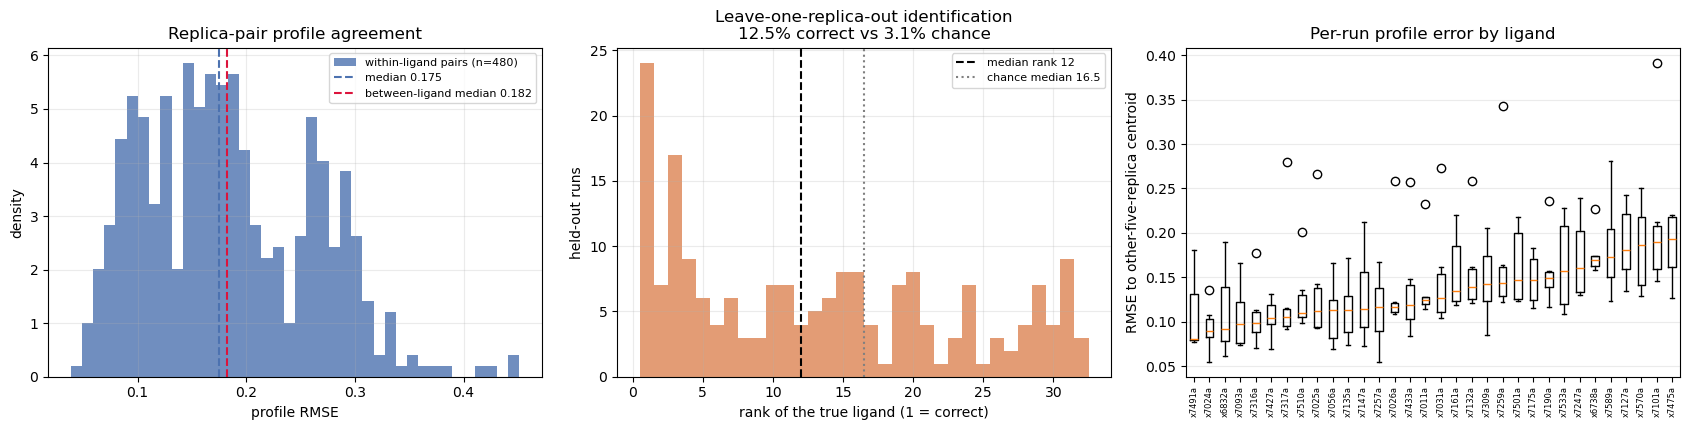


noisiest runs (trajectory-review priorities, NOT failed jobs):
ligand  replicate  rmse_to_other_five_replica_centroid  median_analysis_site_abs_block1_to5_change  sphere_water_mean
x7101a          2                                0.392                                       0.030             64.526
x7259a          2                                0.343                                       0.030             52.804
x7589a          4                                0.281                                       0.034             54.308
x7317a          1                                0.279                                       0.064             48.250

  These runs passed every protocol and topology audit. Their LOW end-to-end block
  drift suggests they sampled a different hydration basin rather than that a file
  is unfinished. Kruskal p = 0.715
  across replica indices: there is no systematically bad replica slot.



In [8]:
# ── Figure — within vs between ligand profile distances ──────────────────────
within = pd.read_csv(REPORT / "within_ligand_replica_pairs.csv")
loo = pd.read_csv(REPORT / "leave_one_replica_out.csv")

if HAVE_MPL:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))

    axes[0].hist(within["rmse"], bins=40, alpha=0.8, color="#4C72B0",
                 label=f"within-ligand pairs (n={len(within)})", density=True)
    axes[0].axvline(rep["median_within_ligand_profile_rmse"], color="#4C72B0", ls="--",
                    label=f"median {rep['median_within_ligand_profile_rmse']:.3f}")
    axes[0].axvline(rep["median_between_ligand_single_run_profile_rmse"], color="crimson",
                    ls="--",
                    label=f"between-ligand median "
                          f"{rep['median_between_ligand_single_run_profile_rmse']:.3f}")
    axes[0].set_xlabel("profile RMSE")
    axes[0].set_ylabel("density")
    axes[0].set_title("Replica-pair profile agreement")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.25)

    ranks = loo["true_ligand_rank"].values
    axes[1].hist(ranks, bins=np.arange(0.5, 33.5, 1), alpha=0.8, color="#DD8452")
    axes[1].axvline(np.median(ranks), color="k", ls="--",
                    label=f"median rank {np.median(ranks):.0f}")
    axes[1].axvline(16.5, color="grey", ls=":", label="chance median 16.5")
    axes[1].set_xlabel("rank of the true ligand (1 = correct)")
    axes[1].set_ylabel("held-out runs")
    axes[1].set_title(f"Leave-one-replica-out identification\n"
                      f"{loo['correct'].mean() * 100:.1f}% correct vs {100 / 32:.1f}% chance")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.25)

    rr = pd.read_csv(REPORT / "run_reproducibility.csv")
    order = rr.groupby("ligand")["rmse_to_other_five_replica_centroid"].median().sort_values()
    data = [rr.loc[rr["ligand"] == lig, "rmse_to_other_five_replica_centroid"].values
            for lig in order.index]
    axes[2].boxplot(data, tick_labels=list(order.index), showfliers=True)
    axes[2].set_xticklabels(list(order.index), rotation=90, fontsize=6)
    axes[2].set_ylabel("RMSE to other-five-replica centroid")
    axes[2].set_title("Per-run profile error by ligand")
    axes[2].grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

rr = pd.read_csv(REPORT / "run_reproducibility.csv")
noisiest = rr.nlargest(4, "rmse_to_other_five_replica_centroid")[
    ["ligand", "replicate", "rmse_to_other_five_replica_centroid",
     "median_analysis_site_abs_block1_to5_change", "sphere_water_mean"]]
print("\nnoisiest runs (trajectory-review priorities, NOT failed jobs):")
print(noisiest.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"""
  These runs passed every protocol and topology audit. Their LOW end-to-end block
  drift suggests they sampled a different hydration basin rather than that a file
  is unfinished. Kruskal p = {rep['replicate_index_kruskal_p_for_profile_error']:.3f}
  across replica indices: there is no systematically bad replica slot.
""")

---
## 6 · The overlapping-label sensitivity check — **the preferred result**

The catalogue contains **7 groups / 15 coordinates** whose centres sit closer than
the 1.4 Å assignment radius. Two such labels can exchange the *same physical
water* through the one-to-one assignment, so a change in one site's occupancy can
describe a **coordinate-label shift rather than water displacement**.

The fix: sum each overlapping component into a regional occupancy and repeat the
ligand-effect test. This collapses 20 supportable sites into **17 neighbourhoods**.

This matters concretely. `HS012`'s individual ligand effect (ICC 0.47) **does not
survive** combination with its 1.02 Å neighbour `HS030` — the regional ICC falls
to 0.04. By contrast the combined `HS008`/`HS013`/`HS015` region stays
ligand-sensitive. **The neighbourhood table takes precedence over isolated
significant p-values on individual coordinates.**

In [9]:
hoods = pd.read_csv(REPORT / "site_neighborhood_statistics.csv")
print(f"neighbourhoods: {len(hoods)}   supported: {int(hoods['supported'].sum())}")
print(f"containing overlapping labels: "
      f"{int(hoods['contains_overlapping_site_labels'].sum())}")

sens = hoods[hoods["ligand_sensitive"]].sort_values("icc_1_1", ascending=False)
cols = ["neighborhood_id", "member_sites", "member_count", "mean_regional_occupancy",
        "icc_1_1", "ligand_mean_range", "lowest_occupancy_ligand", "lowest_ligand_mean",
        "highest_occupancy_ligand", "highest_ligand_mean", "anova_q_bh", "nearest_residues"]
print(f"\nLIGAND-SENSITIVE NEIGHBOURHOODS (q<{Q_THRESHOLD}, ICC>{ICC_THRESHOLD}, "
      f"range>{OCCUPANCY_RANGE_THRESHOLD})")
print(sens[cols].to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print(f"""
  Matches analysis_summary.json:
    {SUMMARY['sites']['robust_ligand_sensitive_neighborhoods']}
""")

# The HS012 -> NG cautionary case, read from the tables rather than asserted.
hs012_row = sites[sites["site_id"] == "HS012"]
if not hs012_row.empty:
    r0 = hs012_row.iloc[0]
    print(f"  Cautionary case — HS012 alone: ICC {r0['icc_1_1']:.3f}, "
          f"range {r0['ligand_mean_range']:.3f}, "
          f"nearest site {r0['nearest_site']} at {r0['nearest_site_distance_A']:.2f} A, "
          f"overlaps={bool(r0['overlaps_another_assignment_sphere'])}")
    owner = hoods[hoods["member_sites"].str.contains("HS012", na=False)]
    if not owner.empty:
        o = owner.iloc[0]
        print(f"  after combination -> {o['neighborhood_id']} ({o['member_sites']}): "
              f"regional ICC {o['icc_1_1']:.3f}, "
              f"ligand_sensitive={bool(o['ligand_sensitive'])}")
        print("  ^ the individual effect DID NOT survive. Report the regional value.")

neighbourhoods: 25   supported: 17
containing overlapping labels: 7

LIGAND-SENSITIVE NEIGHBOURHOODS (q<0.05, ICC>0.25, range>0.15)
neighborhood_id      member_sites  member_count  mean_regional_occupancy  icc_1_1  ligand_mean_range lowest_occupancy_ligand  lowest_ligand_mean highest_occupancy_ligand  highest_ligand_mean  anova_q_bh                nearest_residues
           NG16             HS019             1                    0.487    0.499              0.479                  x7247a               0.129                   x6832a                0.608       0.000                        SER A:87
           NG15             HS018             1                    0.386    0.471              0.164                  x7247a               0.280                   x7491a                0.444       0.000                        ALA A:86
           NG08 HS008;HS013;HS015             3                    0.832    0.397              0.264                  x7309a               0.670                   

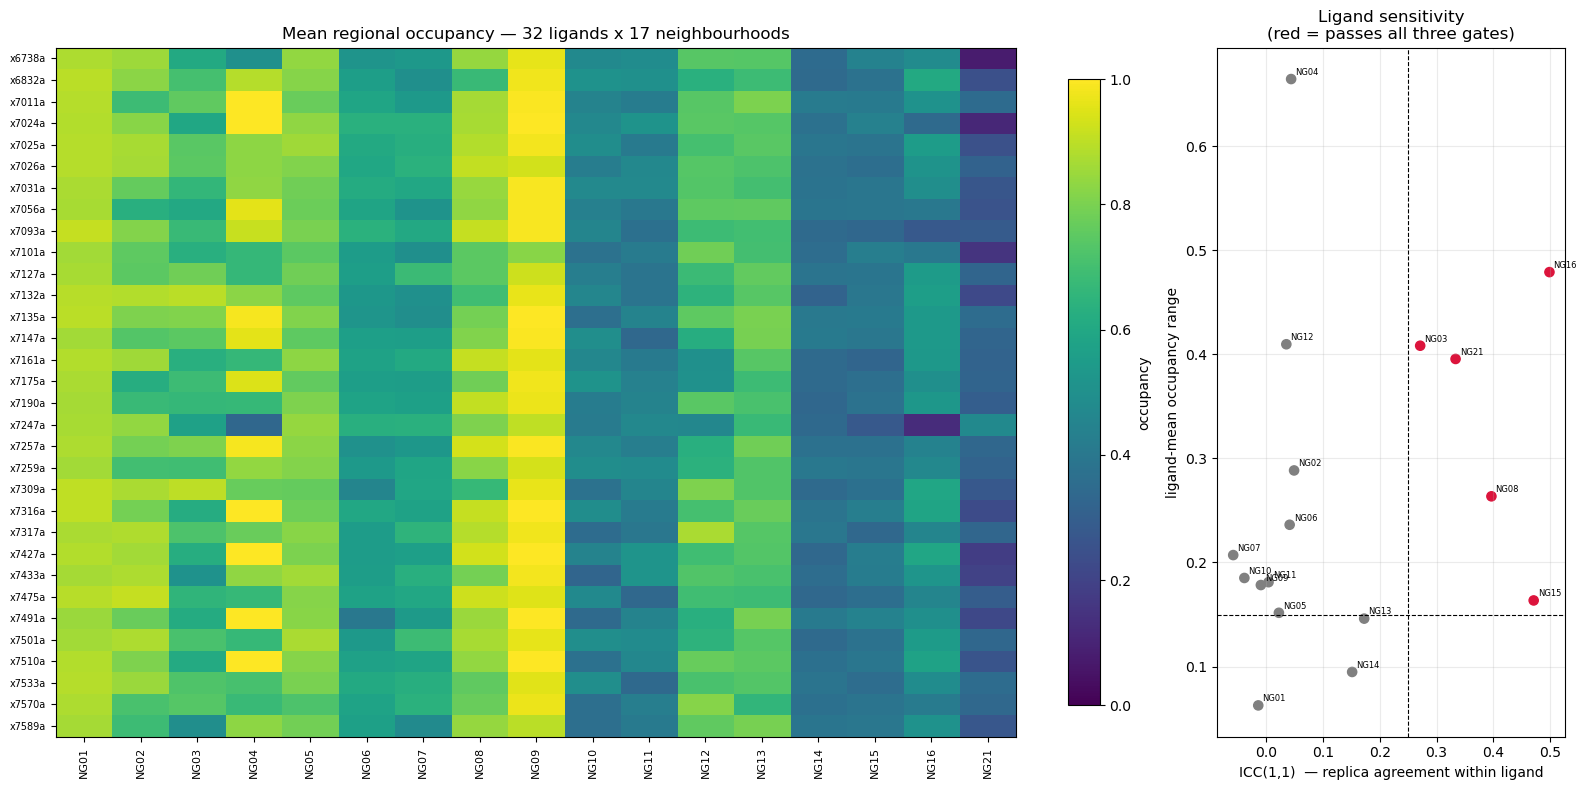

  occupancy matrix: 32 ligands x 17 neighbourhoods
  ICC asks whether replicas of the SAME ligand resemble one another more
  than different ligands do. A high mean occupancy with ICC ~ 0 is a
  SERIES-WIDE structural water, not a ligand discriminator.


In [10]:
# ── Figure — occupancy heatmap over the analysis neighbourhoods ──────────────
nb_means = pd.read_csv(REPORT / "neighborhood_occupancy_ligand_means.csv", index_col=0)
supported = [n for n in SUMMARY["site_filter"]["analysis_neighborhoods"]
             if n in nb_means.columns]
M = nb_means[supported]

if HAVE_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                            gridspec_kw={"width_ratios": [3, 1]})
    im = axes[0].imshow(M.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    axes[0].set_xticks(range(len(M.columns)))
    axes[0].set_xticklabels(M.columns, rotation=90, fontsize=8)
    axes[0].set_yticks(range(len(M.index)))
    axes[0].set_yticklabels(M.index, fontsize=7)
    axes[0].set_title("Mean regional occupancy — 32 ligands x "
                      f"{len(supported)} neighbourhoods")
    fig.colorbar(im, ax=axes[0], label="occupancy", fraction=0.03)

    icc = hoods.set_index("neighborhood_id").loc[supported, "icc_1_1"]
    rng = hoods.set_index("neighborhood_id").loc[supported, "ligand_mean_range"]
    axes[1].scatter(icc, rng, s=44,
                    c=["crimson" if hoods.set_index('neighborhood_id')
                       .loc[n, "ligand_sensitive"] else "grey" for n in supported])
    for n in supported:
        axes[1].annotate(n, (icc[n], rng[n]), fontsize=6,
                         xytext=(3, 3), textcoords="offset points")
    axes[1].axvline(ICC_THRESHOLD, ls="--", lw=0.8, color="k")
    axes[1].axhline(OCCUPANCY_RANGE_THRESHOLD, ls="--", lw=0.8, color="k")
    axes[1].set_xlabel("ICC(1,1)  — replica agreement within ligand")
    axes[1].set_ylabel("ligand-mean occupancy range")
    axes[1].set_title("Ligand sensitivity\n(red = passes all three gates)")
    axes[1].grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

print(f"  occupancy matrix: {M.shape[0]} ligands x {M.shape[1]} neighbourhoods")
print(f"  ICC asks whether replicas of the SAME ligand resemble one another more")
print(f"  than different ligands do. A high mean occupancy with ICC ~ 0 is a")
print(f"  SERIES-WIDE structural water, not a ligand discriminator.")

---
## 7 · Ligand-sensitive regions and the conserved bridge candidate

In [11]:
# ── Consensus sites: high occupancy, ICC near zero ───────────────────────────
consensus = SUMMARY["sites"]["series_consensus"]
print("SERIES-CONSENSUS SITES (shared across the chemical series)")
print("─" * 96)
cols = ["site_id", "mean_occupancy", "icc_1_1", "ligand_mean_range",
        "catalog_support_runs", "nearest_residue", "nearest_distance_A"]
print(sites[sites["site_id"].isin(consensus)][cols]
      .sort_values("mean_occupancy", ascending=False)
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# ── The conserved bridge candidate ────────────────────────────────────────────
bridge_ids = SUMMARY["sites"]["conserved_geometry_only_bridge_candidates"]
print(f"\nCONSERVED PROTEIN-WATER-LIGAND BRIDGE CANDIDATE(S): {bridge_ids}")
print("─" * 96)
bcols = ["site_id", "mean_occupancy", "icc_1_1", "mean_water_bridge_fraction",
         "mean_water_protein_hbond_fraction", "mean_water_ligand_hbond_fraction",
         "mean_ligand_overlap_fraction", "catalog_support_runs",
         "nearest_residue", "nearest_distance_A"]
print(sites[sites["site_id"].isin(bridge_ids)][bcols]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print("""
  HS009 is the standout structural-water hypothesis: mean occupancy 0.967,
  geometry-only bridge fraction 0.468, protein H-bond fraction 0.943, ligand
  H-bond fraction 0.484, nearest GLU A:85.

  Its ICC is approximately ZERO. That means it is shared across the series, so it
  does NOT explain ligand differences — it is a candidate conserved structural
  water, which is a different and separately useful claim.

  Donor/acceptor typing here is geometry-only. Inspect it visually before calling
  it a chemical hydrogen-bond network.
""")

SERIES-CONSENSUS SITES (shared across the chemical series)
────────────────────────────────────────────────────────────────────────────────────────────────
site_id  mean_occupancy  icc_1_1  ligand_mean_range  catalog_support_runs nearest_residue  nearest_distance_A
  HS001           0.880   -0.014              0.063                   190        HIS A:21               2.801
  HS004           0.820    0.044              0.665                   127        PRO A:91               2.597
  HS002           0.795    0.049              0.288                   178       GLY A:103               2.834
  HS005           0.509    0.068              0.135                   101       SER A:105               2.895
  HS003           0.293    0.136              0.217                   145       GLY A:108               3.209

CONSERVED PROTEIN-WATER-LIGAND BRIDGE CANDIDATE(S): ['HS009']
────────────────────────────────────────────────────────────────────────────────────────────────
site_id  mean_occupancy 

---
## 8 · Convergence and sphere-water behaviour

BLOCK DRIFT (production split into 5 blocks)
────────────────────────────────────────────────────────────────────────
  median |occupancy(block 5) - occupancy(block 1)| : 0.048
  fraction of site-runs shifting by more than 0.10 : 0.248

  Five blocks are a practical DRIFT DIAGNOSTIC. They do not prove thermodynamic
  convergence, and must not be reported as if they did. Use the site-level
  columns to separate a stable signal from a drifting one.

SPHERE WATER COUNTS
────────────────────────────────────────────────────────────────────────
  per-run mean range        : 46.6 - 66.5
  instantaneous extrema     : 36 - 83
  Spearman vs experimental pKD: 0.283 (p = 0.116)

  A count of 50-60 waters in a 10 A sphere is NORMAL here and is NOT capped by the
  45-ghost buffer. Ghosts are trial capacity; the sphere count includes ordinary
  physical waters that were already in the solvated system. Confusing the two
  leads to a false 'the buffer is saturating' conclusion.

  Total water count is 

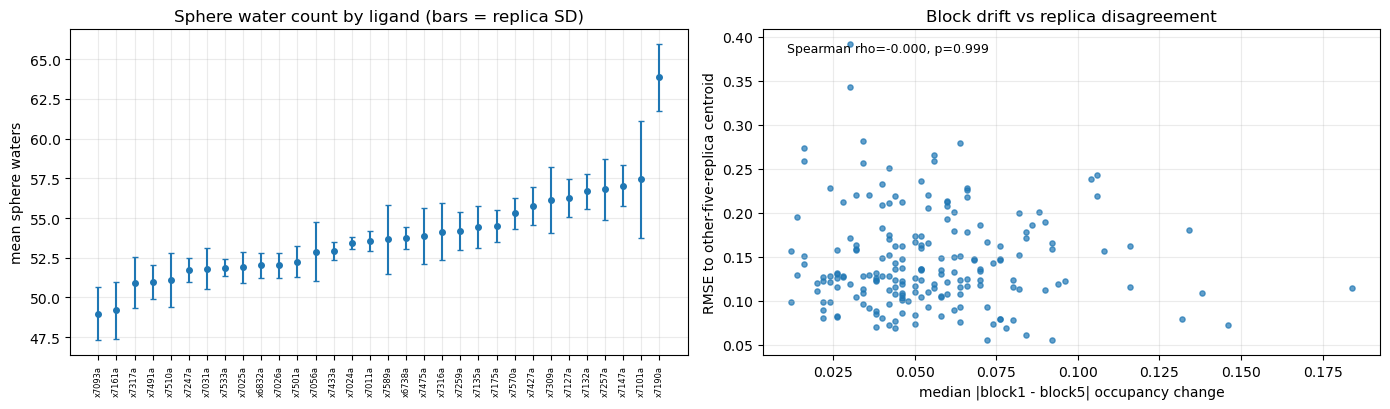

In [12]:
conv = SUMMARY["convergence"]
sw = SUMMARY["sphere_waters"]

print("BLOCK DRIFT (production split into 5 blocks)")
print("─" * 72)
print(f"  median |occupancy(block 5) - occupancy(block 1)| : "
      f"{conv['median_site_run_abs_first_last_block_change']:.3f}")
print(f"  fraction of site-runs shifting by more than 0.10 : "
      f"{conv['fraction_site_runs_abs_change_gt_0_1']:.3f}")
print("""
  Five blocks are a practical DRIFT DIAGNOSTIC. They do not prove thermodynamic
  convergence, and must not be reported as if they did. Use the site-level
  columns to separate a stable signal from a drifting one.
""")

print("SPHERE WATER COUNTS")
print("─" * 72)
print(f"  per-run mean range        : {sw['run_mean_range'][0]:.1f} - {sw['run_mean_range'][1]:.1f}")
print(f"  instantaneous extrema     : {sw['absolute_observed_range'][0]} - "
      f"{sw['absolute_observed_range'][1]}")
print(f"  Spearman vs experimental pKD: {sw['spearman_vs_pKD']:.3f} (p = {sw['p_value']:.3f})")
print("""
  A count of 50-60 waters in a 10 A sphere is NORMAL here and is NOT capped by the
  45-ghost buffer. Ghosts are trial capacity; the sphere count includes ordinary
  physical waters that were already in the solvated system. Confusing the two
  leads to a false 'the buffer is saturating' conclusion.

  Total water count is also not the useful object. The useful object is the vector
  of probabilities that matched spatial sites are occupied, displaced by ligand
  atoms, or bridging.
""")

wc = pd.read_csv(REPORT / "run_water_counts.csv")
if HAVE_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    order = wc.groupby("ligand")["sphere_water_mean"].mean().sort_values()
    axes[0].errorbar(
        range(len(order)), order.values,
        yerr=[wc.loc[wc["ligand"] == l, "sphere_water_mean"].std() for l in order.index],
        fmt="o", ms=4, capsize=2)
    axes[0].set_xticks(range(len(order)))
    axes[0].set_xticklabels(order.index, rotation=90, fontsize=6)
    axes[0].set_ylabel("mean sphere waters")
    axes[0].set_title("Sphere water count by ligand (bars = replica SD)")
    axes[0].grid(alpha=0.25)

    rr2 = pd.read_csv(REPORT / "run_reproducibility.csv")
    axes[1].scatter(rr2["median_analysis_site_abs_block1_to5_change"],
                    rr2["rmse_to_other_five_replica_centroid"], s=14, alpha=0.7)
    axes[1].set_xlabel("median |block1 - block5| occupancy change")
    axes[1].set_ylabel("RMSE to other-five-replica centroid")
    axes[1].set_title("Block drift vs replica disagreement")
    axes[1].grid(alpha=0.25)
    if HAVE_SCIPY:
        rho, p = stats.spearmanr(rr2["median_analysis_site_abs_block1_to5_change"],
                                 rr2["rmse_to_other_five_replica_centroid"])
        axes[1].annotate(f"Spearman rho={rho:.3f}, p={p:.3g}", (0.04, 0.93),
                         xycoords="axes fraction", fontsize=9)
    fig.tight_layout()
    plt.show()

---
## 9 · Chemistry and affinity relationships

Both are **exploratory**. The common catalogue and the hypotheses were derived
from the same 32 compounds, so these are descriptive, not held-out validation.

CHEMICAL SIMILARITY vs HYDRATION SIMILARITY
──────────────────────────────────────────────────────────────────────────────
  Spearman(Morgan Tanimoto, hydration profile RMSE) = -0.177
  asymptotic p   : 7.10e-05
  PERMUTATION p  : 0.0300    <- use this one

  The sign is negative, as expected if chemically similar ligands retain similar
  hydration. Quote the PERMUTATION p: the 496 pairwise values are not independent
  (each ligand appears in 31 pairs), so the asymptotic p is anticonservative by
  orders of magnitude here (7e-05 vs 0.030).

  This is a series-level sanity check. It is not a binding model.

AFFINITY ASSOCIATIONS (BH-corrected)
──────────────────────────────────────────────────────────────────────────────
  all sites,        q < 0.05 : ['HS005', 'HS008', 'HS014', 'HS031']
  supported sites,  q < 0.05 : ['HS005', 'HS008', 'HS014']
  supported NEIGHBOURHOODS   : ['NG05']

  Four individual coordinates survive correction, but one (HS031) is a
  tentative-low-support entry. 

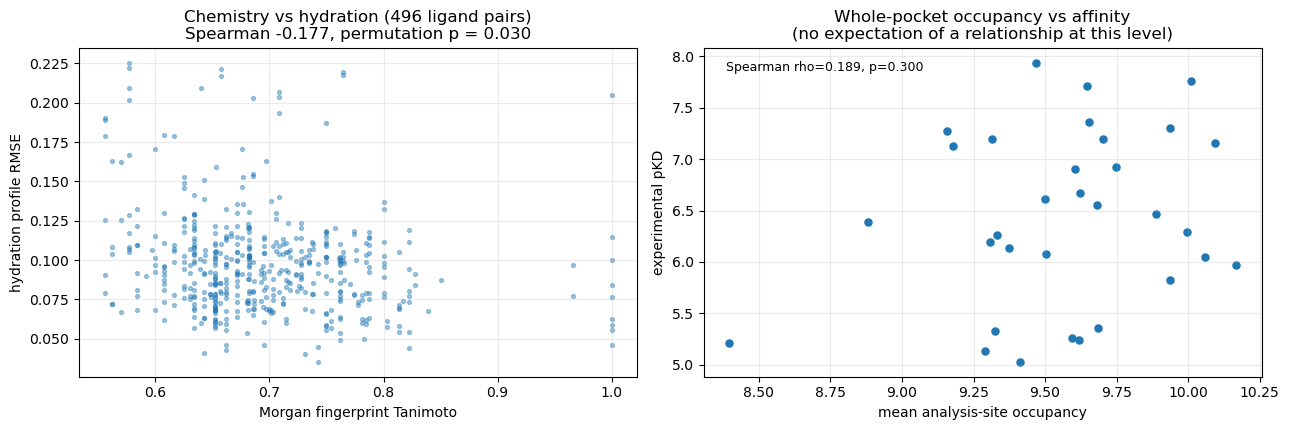

In [13]:
cv = SUMMARY["chemical_vs_hydration"]
aff = SUMMARY["affinity"]

print("CHEMICAL SIMILARITY vs HYDRATION SIMILARITY")
print("─" * 78)
print(f"  Spearman(Morgan Tanimoto, hydration profile RMSE) = "
      f"{cv['spearman_tanimoto_vs_hydration_rmse']:.3f}")
print(f"  asymptotic p   : {cv['asymptotic_p']:.2e}")
print(f"  PERMUTATION p  : {cv['permutation_p']:.4f}    <- use this one")
print("""
  The sign is negative, as expected if chemically similar ligands retain similar
  hydration. Quote the PERMUTATION p: the 496 pairwise values are not independent
  (each ligand appears in 31 pairs), so the asymptotic p is anticonservative by
  orders of magnitude here (7e-05 vs 0.030).

  This is a series-level sanity check. It is not a binding model.
""")

print("AFFINITY ASSOCIATIONS (BH-corrected)")
print("─" * 78)
print(f"  all sites,        q < 0.05 : {aff['all_sites_bh_q_lt_0_05']}")
print(f"  supported sites,  q < 0.05 : {aff['supported_sites_bh_q_lt_0_05']}")
print(f"  supported NEIGHBOURHOODS   : {aff['supported_neighborhoods_bh_q_lt_0_05']}")
print("""
  Four individual coordinates survive correction, but one (HS031) is a
  tentative-low-support entry. After repeating on non-overlapping neighbourhoods
  the supported association reduces to NG05 (HS005;HS028).

  Report NG05. Do not report the four raw site-level hits as four findings.
""")

chem = pd.read_csv(REPORT / "chemical_hydration_pairwise.csv")
if HAVE_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    axes[0].scatter(chem["tanimoto"], chem["hydration_rmse"], s=8, alpha=0.4)
    axes[0].set_xlabel("Morgan fingerprint Tanimoto")
    axes[0].set_ylabel("hydration profile RMSE")
    axes[0].set_title(f"Chemistry vs hydration ({len(chem)} ligand pairs)\n"
                      f"Spearman {cv['spearman_tanimoto_vs_hydration_rmse']:.3f}, "
                      f"permutation p = {cv['permutation_p']:.3f}")
    axes[0].grid(alpha=0.25)

    ligstats = pd.read_csv(REPORT / "ligand_statistics.csv")
    ok = ligstats.dropna(subset=["experimental_pKD"])
    axes[1].scatter(ok["mean_analysis_site_occupancy"], ok["experimental_pKD"], s=26)
    axes[1].set_xlabel("mean analysis-site occupancy")
    axes[1].set_ylabel("experimental pKD")
    axes[1].set_title("Whole-pocket occupancy vs affinity\n"
                      "(no expectation of a relationship at this level)")
    axes[1].grid(alpha=0.25)
    if HAVE_SCIPY and len(ok) > 3:
        rho, p = stats.spearmanr(ok["mean_analysis_site_occupancy"], ok["experimental_pKD"])
        axes[1].annotate(f"Spearman rho={rho:.3f}, p={p:.3f}", (0.04, 0.93),
                         xycoords="axes fraction", fontsize=9)
    fig.tight_layout()
    plt.show()

In [14]:
# ── Replicate-averaging report: what averaging six replicas actually buys ────
rep_summary = REPLICATE_REPORT / "replicate_average_summary.json"
if rep_summary.is_file():
    RS = json.loads(rep_summary.read_text())

    def walk(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                walk(v, prefix + k + ".")
            elif isinstance(v, (int, float, str, bool)) or v is None:
                print(f"  {prefix + k:<58} {v}")

    print("REPLICATE-AVERAGE SUMMARY")
    print("─" * 84)
    walk(RS)
    print(f"\n  tables: {sorted(p.name for p in REPLICATE_REPORT.glob('*.csv'))}")
else:
    print(f"replicate-average summary absent: {rep_summary}")

REPLICATE-AVERAGE SUMMARY
────────────────────────────────────────────────────────────────────────────────────
  analysis_unit                                              32 ligands; each ligand estimate is the mean of six independent replicas
  ligands                                                    32
  replicas_per_ligand                                        6
  supported_neighborhoods                                    17
  ligand_neighborhood_estimates                              544
  within_ligand_replica_range.q25                            0.11409999999999995
  within_ligand_replica_range.median                         0.21639999999999998
  within_ligand_replica_range.q75                            0.36029999999999995
  within_ligand_replica_range.p90                            0.53004
  within_ligand_replica_range.p95                            0.6567600000000001
  uncertainty_of_six_replica_mean_profile.median_rms_sem     0.055820275563771754
  uncertainty_of_six_repl

---
## 10 · Recap

**The run stands up.** 192/192 runs pass the canonical schedule, topology-handoff
and reconstruction audits. Zero protocol deviations, zero analysis-validation
deviations, prepared poses within 0.0006 Å of their supplied SDF records, exactly
45 inactive ghosts in every raw topology and zero in every physical one.

**The scientific result is mixed, and both halves must be reported.**

| Claim | Supported? |
|---|---|
| specific pocket regions are ligand-sensitive | **yes** — NG16, NG15, NG08, NG21, NG03 |
| a conserved structural-water candidate exists | **yes** — HS009, occupancy 0.967, nearest GLU A:85 |
| averaging 6 replicas suppresses replica noise | **yes** — mean-profile separation 0.094 vs single-run 0.182 |
| each ligand has a reproducible whole-pocket signature | **no** — P(between>within) = 0.547, LOO accuracy 12.5 % |
| hydration profiles predict affinity | **no** — one exploratory neighbourhood (NG05), same-compound derivation |

**The methodological point that generalises.** Site labels closer than the
assignment radius can exchange a physical water, so an individual-site "effect"
may be a label shift. Always repeat the test on non-overlapping neighbourhoods
and report *that*. HS012 (ICC 0.47 alone → 0.04 regional) is the worked example.

**What Project 2 should carry forward.** Not the total water count — the vector
of per-site probabilities: occupied, displaced by ligand atoms, or bridging. Six
replicas give each probability an error bar. A site is useful when the six
replicas agree within a ligand, different ligands give distinct means, its block
history is stable, and its location makes structural sense.

**Caveats to keep attached to any reuse.**

1. The catalogue was learned from all 192 runs → tests are descriptive.
2. Bridge/H-bond flags are geometry-only candidates.
3. Low-support catalogue entries are hypotheses, not sites.
4. Five blocks diagnose drift; they do not prove convergence.
5. Occupancy is not residence time — GCMC destroys water identity by design.
6. The ligand poses are Rowan docked poses, not crystal poses (§1).

**Next:** notebook 06 uses these equilibrated waters to seed relative FEP —
including the frame-registration defect that makes `--align-to-bound-pose`
load-bearing, and the environment failure that killed the first network.